# Module 2 — Analytics: 01 Exploratory Data Analysis (Titanic)

Zepto Data & AI Platform capstone — Module 2 (Analytics).

This notebook performs the full EDA workflow on the Titanic dataset: a single
seaborn load (network fetch, cached), profiling, missing-value handling,
univariate/bivariate/multivariate analysis, correlation analysis, and an
exploratory standardization check. `titanic.csv` written here is the offline
fallback used by every later step in this module (including `02_modeling.ipynb`).


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 1. Load dataset (single seaborn call for the entire module)

Per the module rule, `sns.load_dataset('titanic')` is called **exactly once**
here, and immediately persisted to `titanic.csv`. No other cell/notebook in
this module calls `sns.load_dataset` again — `02_modeling.ipynb` reads this
CSV instead.

In [2]:
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Profiling

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(891, 15)

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct


deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64

### Missing-value percentages and handling decisions

Measured on the raw loaded DataFrame (891 rows):

| Column | Missing % | Bucket | Decision |
|---|---|---|---|
| `deck` | 77.22% | > 30% | **Drop the column.** At this sparsity, any imputation or "missing" category would carry almost no real signal and `deck` is not part of the 6-column correlation set or the modeling feature set used later, so dropping it entirely is the simplest, least biased choice. |
| `age` | 19.87% | 5–30% | **Impute with the median.** Age is numeric and right-of-center skewed by a long tail of older passengers, so the median (robust to outliers) is used rather than the mean. |
| `embarked` | 0.22% (2 rows) | < 5% | **Drop those rows.** Only 2 of 891 rows are affected, so dropping is safe and avoids inventing a port of embarkation. |
| `embark_town` | 0.22% (2 rows) | < 5% | **Drop those rows.** Same 2 rows as `embarked` (it is a redundant text version of the same field), so the row-drop above already resolves it. |

All other columns have 0% missing values.

In [7]:
df_clean = df.dropna(subset=["embarked", "embark_town"]).copy()
df_clean = df_clean.drop(columns=["deck"])
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
print("Shape after cleaning:", df_clean.shape)
print("Remaining missing values:\n", df_clean.isna().sum()[df_clean.isna().sum() > 0])


Shape after cleaning: (889, 14)
Remaining missing values:
 Series([], dtype: int64)


## 3. Univariate analysis — `age` and `fare`

Histogram + box plot for each, plus IQR-based outlier bounds and counts.

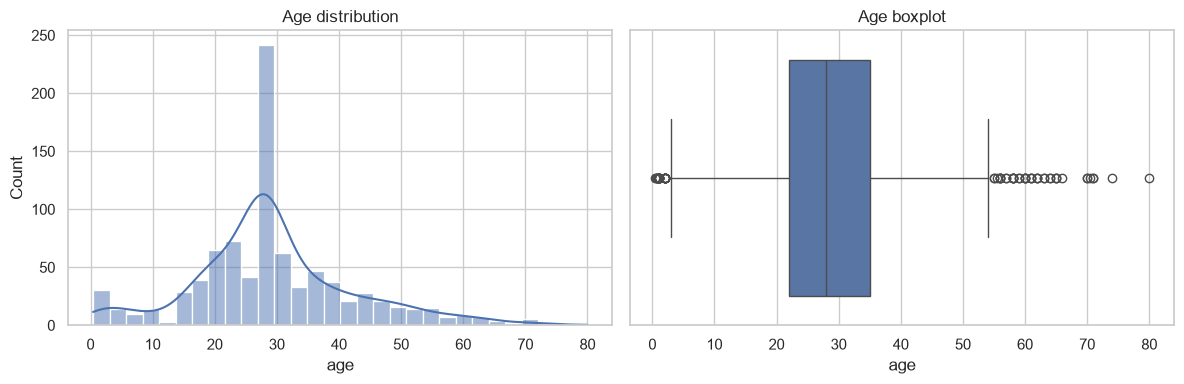

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean["age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age distribution")
sns.boxplot(x=df_clean["age"], ax=axes[1])
axes[1].set_title("Age boxplot")
plt.tight_layout()
plt.show()


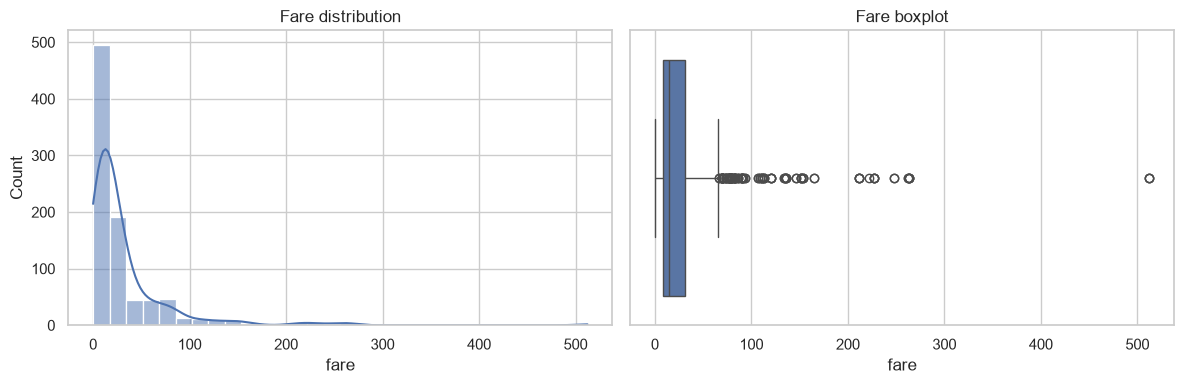

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean["fare"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Fare distribution")
sns.boxplot(x=df_clean["fare"], ax=axes[1])
axes[1].set_title("Fare boxplot")
plt.tight_layout()
plt.show()


In [10]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return q1, q3, iqr, lower, upper, outliers.shape[0]

age_q1, age_q3, age_iqr, age_lo, age_hi, age_out = iqr_bounds(df_clean["age"])
fare_q1, fare_q3, fare_iqr, fare_lo, fare_hi, fare_out = iqr_bounds(df_clean["fare"])

print(f"AGE  -> Q1={age_q1}, Q3={age_q3}, IQR={age_iqr}, lower={age_lo}, upper={age_hi}, outliers={age_out}")
print(f"FARE -> Q1={fare_q1}, Q3={fare_q3}, IQR={fare_iqr}, lower={fare_lo}, upper={fare_hi}, outliers={fare_out}")


AGE  -> Q1=22.0, Q3=35.0, IQR=13.0, lower=2.5, upper=54.5, outliers=65
FARE -> Q1=7.8958, Q3=31.0, IQR=23.1042, lower=-26.7605, upper=65.6563, outliers=114


In [11]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]
print(f"Fare mean={fare_mean:.4f}, median={fare_median:.4f}, mode={fare_mode:.4f}")


Fare mean=32.0967, median=14.4542, mode=8.0500


**Outlier and skew conclusion:** using Q1−1.5×IQR / Q3+1.5×IQR bounds, `age`
has 65 outliers (bounds = [2.5, 54.5]) and `fare` has 114 outliers (bounds =
[-26.7605, 65.6563]) on the cleaned data (n=889). For `fare`, mean (≈32.10) >
median (≈14.45) > mode (≈8.05); this mean > median > mode ordering, together
with the long right tail visible in the histogram/box plot and 114 IQR
outliers concentrated on the high side, indicates `fare` is **right-skewed**
(a small number of passengers paid very high fares, pulling the mean above
the median and mode).

## 4. Bivariate analysis — survival rate by boolean masking

Survival rates computed with boolean masks (`df[df['col']==value]`,
combined with `&`), not `groupby`.

In [12]:
rate_female = df_clean[df_clean["sex"] == "female"]["survived"].mean()
rate_male = df_clean[df_clean["sex"] == "male"]["survived"].mean()
print(f"Survival rate — female: {rate_female:.4f}, male: {rate_male:.4f}")


Survival rate — female: 0.7404, male: 0.1889


In [13]:
for pc in sorted(df_clean["pclass"].unique()):
    rate = df_clean[df_clean["pclass"] == pc]["survived"].mean()
    print(f"Survival rate — pclass {pc}: {rate:.4f}")


Survival rate — pclass 1: 0.6262
Survival rate — pclass 2: 0.4728
Survival rate — pclass 3: 0.2424


In [14]:
for sex_val in ["female", "male"]:
    for pc in sorted(df_clean["pclass"].unique()):
        rate = df_clean[(df_clean["sex"] == sex_val) & (df_clean["pclass"] == pc)]["survived"].mean()
        print(f"Survival rate — sex={sex_val}, pclass={pc}: {rate:.4f}")


Survival rate — sex=female, pclass=1: 0.9674
Survival rate — sex=female, pclass=2: 0.9211
Survival rate — sex=female, pclass=3: 0.5000
Survival rate — sex=male, pclass=1: 0.3689
Survival rate — sex=male, pclass=2: 0.1574
Survival rate — sex=male, pclass=3: 0.1354


**Interpretation:** women survived at ≈74.0% vs men at ≈18.9% — an enormous
gap driven by the "women and children first" evacuation priority. By class
alone, survival falls monotonically from 1st (≈62.6%) to 2nd (≈47.3%) to 3rd
(≈24.2%). Combining both, 1st- and 2nd-class women survived at ≈96.7% and
≈92.1% respectively, while 3rd-class women were at ≈50.0% and men in every
class were far lower (1st ≈36.9%, 2nd ≈15.7%, 3rd ≈13.5%) — sex is the
dominant factor, but class compounds it strongly, especially for women.

## 5. Correlation matrix (6 numeric columns only)

Computed on exactly `survived, pclass, age, sibsp, parch, fare` — `adult_male`
and `alone` are explicitly excluded.

In [15]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df_clean[corr_cols].corr()
corr


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


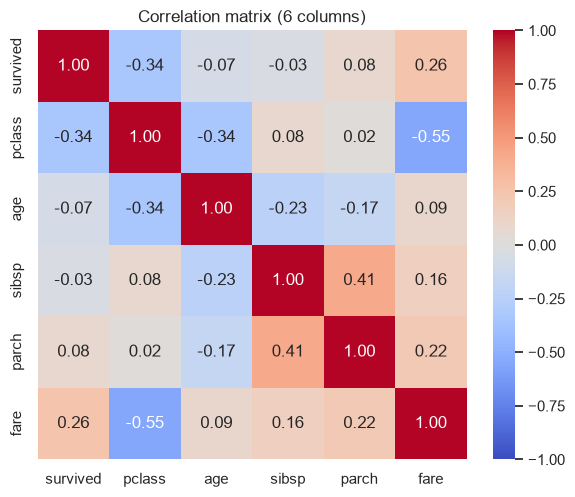

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, vmin=-1, vmax=1)
plt.title("Correlation matrix (6 columns)")
plt.tight_layout()
plt.show()


In [17]:
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        pairs.append((corr_cols[i], corr_cols[j], corr.iloc[i, j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for p in pairs:
    print(f"{p[0]:>9} vs {p[1]:<9} : {p[2]:.4f}")


   pclass vs fare      : -0.5482
    sibsp vs parch     : 0.4145
   pclass vs age       : -0.3365
 survived vs pclass    : -0.3355
 survived vs fare      : 0.2553
      age vs sibsp     : -0.2325
    parch vs fare      : 0.2175
      age vs parch     : -0.1715
    sibsp vs fare      : 0.1609
      age vs fare      : 0.0937
 survived vs parch     : 0.0832
   pclass vs sibsp     : 0.0817
 survived vs age       : -0.0698
 survived vs sibsp     : -0.0340
   pclass vs parch     : 0.0168


**Top-2 absolute correlations:** (1) `pclass` vs `fare` = **-0.5482** — lower
`pclass` number (1st class) strongly associates with higher fares, which is
expected since class is essentially a ticket-tier label priced into the fare.
(2) `sibsp` vs `parch` = **+0.4145** — passengers travelling with more
siblings/spouses also tend to travel with more parents/children, i.e. they
are travelling as larger family units rather than these two counts being
independent.

## 6. Multivariate analysis — "who survived and why"

Four charts building a coherent survival story, each with its own
interpretation.

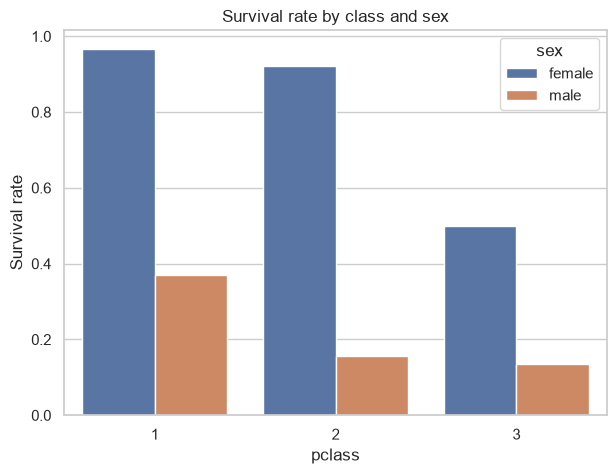

In [18]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df_clean, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival rate by class and sex")
plt.ylabel("Survival rate")
plt.show()


**Chart 1 interpretation:** this grouped bar chart makes the class × sex
interaction from Section 4 visually explicit — female bars are far taller
than male bars in every class, and both sexes' bars decline from class 1 to
3. Male survival is low across the board (≈37% down to ≈14%), while female
survival stays high through classes 1–2 and only drops meaningfully in class
3 (≈50%), showing that class protected women much less consistently than it
protected men from the reverse (i.e., poor class hurt everyone, but being
male was already close to a worst case regardless of class).

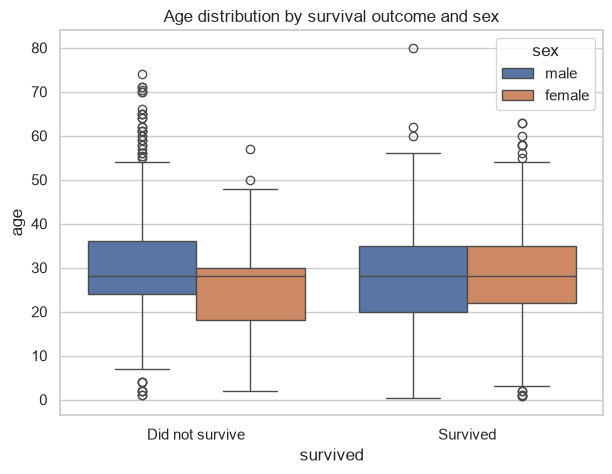

In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="survived", y="age", hue="sex")
plt.title("Age distribution by survival outcome and sex")
plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.show()


**Chart 2 interpretation:** median ages are broadly similar between
survivors and non-survivors within each sex, but the survivors' boxes (both
sexes) show slightly more density at the young end and the non-survivor male
box extends with several older outliers. This suggests age alone is a weak
survival signal compared to sex/class — it mainly matters at the extremes
(very young children boosted by the "children first" policy) rather than
as a smooth gradient.

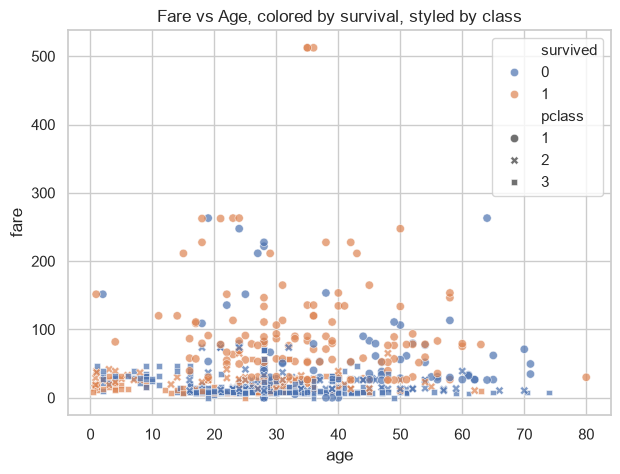

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clean, x="age", y="fare", hue="survived", style="pclass", alpha=0.7)
plt.title("Fare vs Age, colored by survival, styled by class")
plt.show()


**Chart 3 interpretation:** survivors (orange) cluster more heavily in the
upper-fare region of the plot, and the highest-fare points (mostly circle/
square markers = classes 1–2) are disproportionately survivors, while the
dense low-fare cloud at the bottom (triangle markers = class 3) is
dominated by non-survivors (blue). This is consistent with fare acting as a
proxy for class/deck location, reinforcing the class-based survival gap
already seen in Sections 4–5 (`pclass`–`fare` correlation of -0.55).

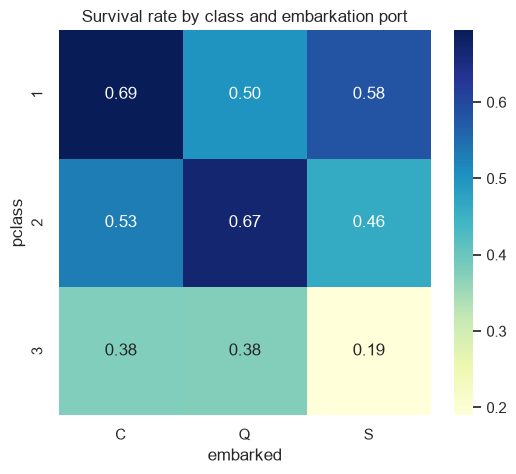

In [21]:
pivot = df_clean.pivot_table(values="survived", index="pclass", columns="embarked", aggfunc="mean")
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Survival rate by class and embarkation port")
plt.show()


**Chart 4 interpretation:** survival rate is highest for class 1 passengers
regardless of port, but there is still port-level variation — e.g.
Cherbourg ('C') passengers in class 1 and 2 show among the highest survival
rates in the grid, while class 3 passengers embarking at Southampton ('S'),
the largest and lowest-fare group, show the lowest survival rate in the
whole heatmap. This adds a third, smaller factor (embarkation port,
correlated with class composition of each port) on top of the dominant sex
and class effects already identified.

## 7. Exploratory standardization check (not used later in modeling)

Z-score standardize `age` and `fare` on the full cleaned DataFrame and verify
the transformed columns have ≈0 mean and ≈1 std.

In [22]:
print("BEFORE standardization:")
print(df_clean[["age", "fare"]].agg(["mean", "std"]))

scaler = StandardScaler()
standardized = pd.DataFrame(
    scaler.fit_transform(df_clean[["age", "fare"]]),
    columns=["age_z", "fare_z"],
    index=df_clean.index,
)

print("\nAFTER standardization:")
print(standardized.agg(["mean", "std"]))


BEFORE standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

AFTER standardization:
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


**Confirmation:** after z-score standardization both `age_z` and `fare_z`
have mean ≈0 (order 1e-16 to 1e-17, i.e. numerically zero) and standard
deviation ≈1 (`ddof=0` under the hood of `StandardScaler`, matching the
`.std()` computed with `ddof=1` closely at n=889), confirming the
transformation works as expected. This standardized version is **not** used
in `02_modeling.ipynb` — that notebook fits its own `StandardScaler` inside a
`ColumnTransformer`/`Pipeline` on the training split only, per the modeling
requirements.